In [44]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import rasterio
import numpy as np
import xarray as xr

## A lightweight notebook providing code for the visualization of geospatial data downloaded via CLUES.

### 1st socioeconomic data from espon

In [10]:
# load geometries
geometries_path = 'test_data\\espon\\geometry.csv'
# Load the CSV file into a pandas DataFrame
gdf = pd.read_csv(geometries_path)

# Convert the 'geometry' column to actual geometrical data using shapely
gdf['geometry'] = gdf['geometry'].apply(wkt.loads)

# Convert the pandas DataFrame to a GeoPandas GeoDataFrame
gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

# Set the current coordinate reference system (CRS)
gdf.set_crs(epsg=4326, inplace=True)


,geometry,tunit_code
0,"POLYGON ((16.02442 47.38532, 16.04583 47.39272...",AT11
1,"POLYGON ((13.57837 47.4107, 13.57786 47.41138,...",AT22
2,"POLYGON ((14.46053 48.06805, 14.46171 48.06858...",AT12
3,"POLYGON ((16.19393 48.22388, 16.25562 48.23942...",AT13
4,"POLYGON ((12.73732 47.11885, 12.84519 47.11302...",AT21
...,...,...
3288,"POLYGON ((-0.38119 52.41218, -0.38176 52.4414,...",UKH1
3289,"MULTIPOLYGON (((-0.35391 42.90804, -0.30195 42...",FRJ2
3290,"POLYGON ((-0.01695 51.69028, -0.01228 51.69725...",UKH3
3291,"POLYGON ((-0.93636 53.70488, -0.95523 53.75601...",UKE1


In [122]:
# load dataOI
filepath = "test_data\\espon\\Educational_attainment_level_by_age_group\\Population_-_age_group_25-64_-_with_educational_attainment_level_5-8_.csv"

df = pd.read_csv(filepath)

# Merging data and geometries on the 'tunit_code' column
data_gdf = pd.merge(gdf, df, on='tunit_code')

# Filter where column 'c' starts with 'SE', 'NR' or 'FI' and 'NUTS2' (length is 4).
filtered_df = data_gdf[data_gdf['tunit_code'].str.startswith(('SE', 'NO', 'FI','EE'))]
filtered_df = filtered_df[filtered_df['tunit_code'].str.len()==4]

filtered_df.head(2)


,geometry,tunit_code,id,name,code,nomenclature,level,version,tunit_name,processes,...,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2017,y_2018,y_2019,y_2020
96,"MULTIPOLYGON (((21.75966 58.34949, 21.78258 58...",EE00,299,Population - age group 25-64 - with educationa...,25-64_T_5-8,NUTS,2,2016,Eesti,NaN,...,36.9,37.6,37.4,37.6,38.1,38.9,39.7,41.2,41.4,42.3
99,"MULTIPOLYGON (((20.9883 60.73435, 21.02219 60....",FI1C,299,Population - age group 25-64 - with educationa...,25-64_T_5-8,NUTS,2,2016,Etela-Suomi,NaN,...,35.4,36.0,36.2,38.1,38.9,38.8,39.8,40.9,42.6,43.5


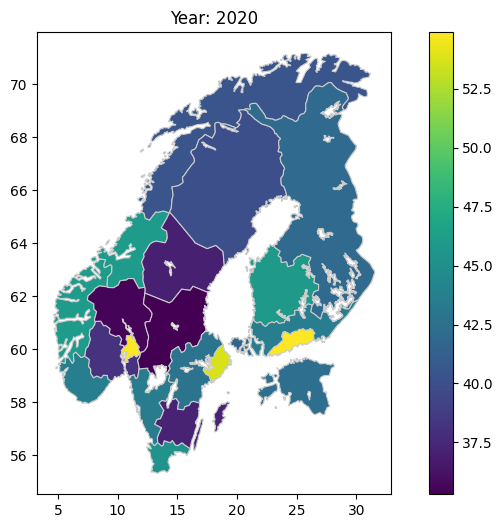

In [123]:
# Define the year you want to plot
year = 2020

# Create the 'x' column from the selected year
filtered_df['x'] = filtered_df[f'y_{year}']

# Create the axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot
filtered_df.plot(
    column='x',
    cmap='viridis',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

# Set title
ax.set_title(f"Year: {year}")

# Show plot
plt.show()

### 2nd geoTiff (Modis NVDI)

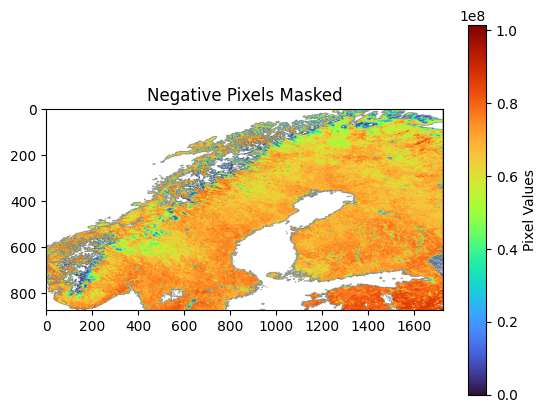

In [42]:
# Open the GeoTIFF file
with rasterio.open('test_data/modis_ndvi/2020-06-01.tif') as src:
    image = src.read(1)  # Read the first band

masked = np.ma.masked_less(image, 0)
plt.imshow(masked, cmap='turbo')
plt.title('Negative Pixels Masked')
plt.colorbar(label='Pixel Values')
plt.show()

### 3rd Air pollution netcdf (cams reanalysis)

<xarray.Dataset> Size: 7MB
Dimensions:     (valid_time: 2928, latitude: 18, longitude: 35)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 23kB 2020-01-01 ... 2020-12-31T21...
  * latitude    (latitude) float64 144B 70.71 69.96 69.21 ... 59.46 58.71 57.96
  * longitude   (longitude) float64 280B 4.992 5.742 6.492 ... 28.99 29.74 30.49
Data variables:
    bcaod550    (valid_time, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-05-13T12:48 GRIB to CDM+CF via cfgrib-0.9.1...


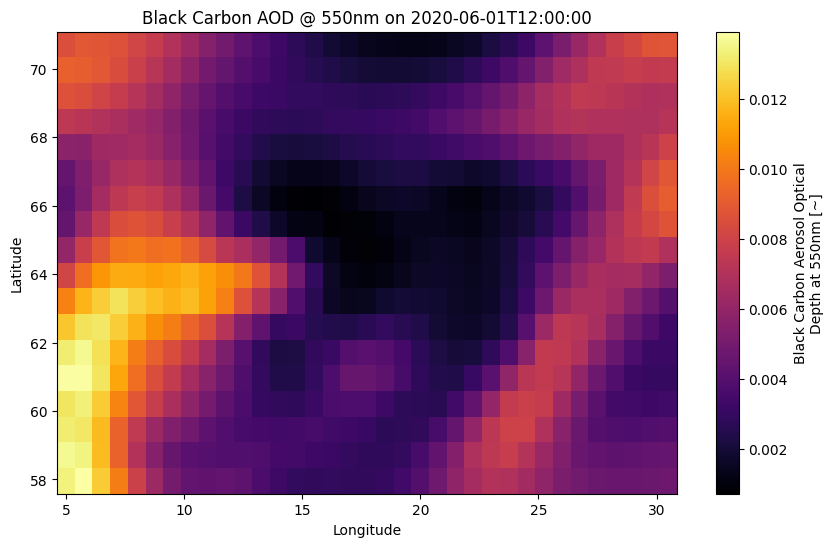

In [91]:
# Open the NetCDF file
ds = xr.open_dataset('test_data/black_carbon_aerosol_optical_depth_550nm_norway/2020.nc')

# Inspect the dataset
print(ds)

# Select data for a specific date
date = '2020-06-01T12:00:00'
data_on_date = ds.sel(valid_time =date)

bcaod = data_on_date['bcaod550']

# Plot it
plt.figure(figsize=(10, 6))
bcaod.plot(cmap='inferno')  # or 'viridis', 'plasma', etc.
plt.title(f"Black Carbon AOD @ 550nm on {date}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 4th climate netcdf (era5 reanalsis)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 720, latitude: 53, longitude: 105)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-06-01 ... 2020-06-30T23:...
  * latitude    (latitude) float64 424B 70.96 70.71 70.46 ... 58.46 58.21 57.96
  * longitude   (longitude) float64 840B 4.992 5.242 5.492 ... 30.49 30.74 30.99
    expver      (valid_time) <U4 12kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 16MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-05-12T10:45 GRIB to CDM+CF via cfgrib-0.9.1...


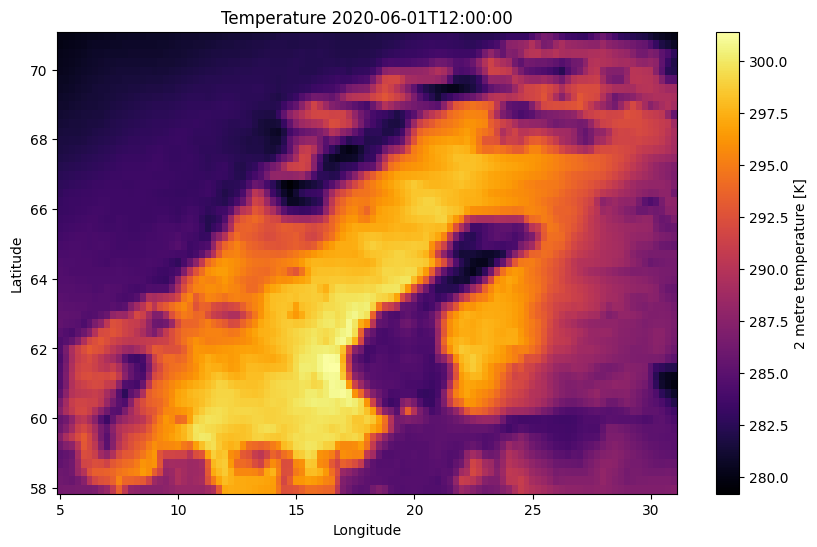

In [92]:
# Open the NetCDF file
ds = xr.open_dataset('test_data/era5_temperature_norway/june_2020.nc')

# Inspect the dataset
print(ds)

# Select data for a specific date
date = '2020-06-01T12:00:00'
data_on_date = ds.sel(valid_time =date)

t2m = data_on_date['t2m']

# Plot it
plt.figure(figsize=(10, 6))
t2m.plot(cmap='inferno')  # or 'viridis', 'plasma', etc.
plt.title(f"Temperature {date}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 5th All togther in one plot

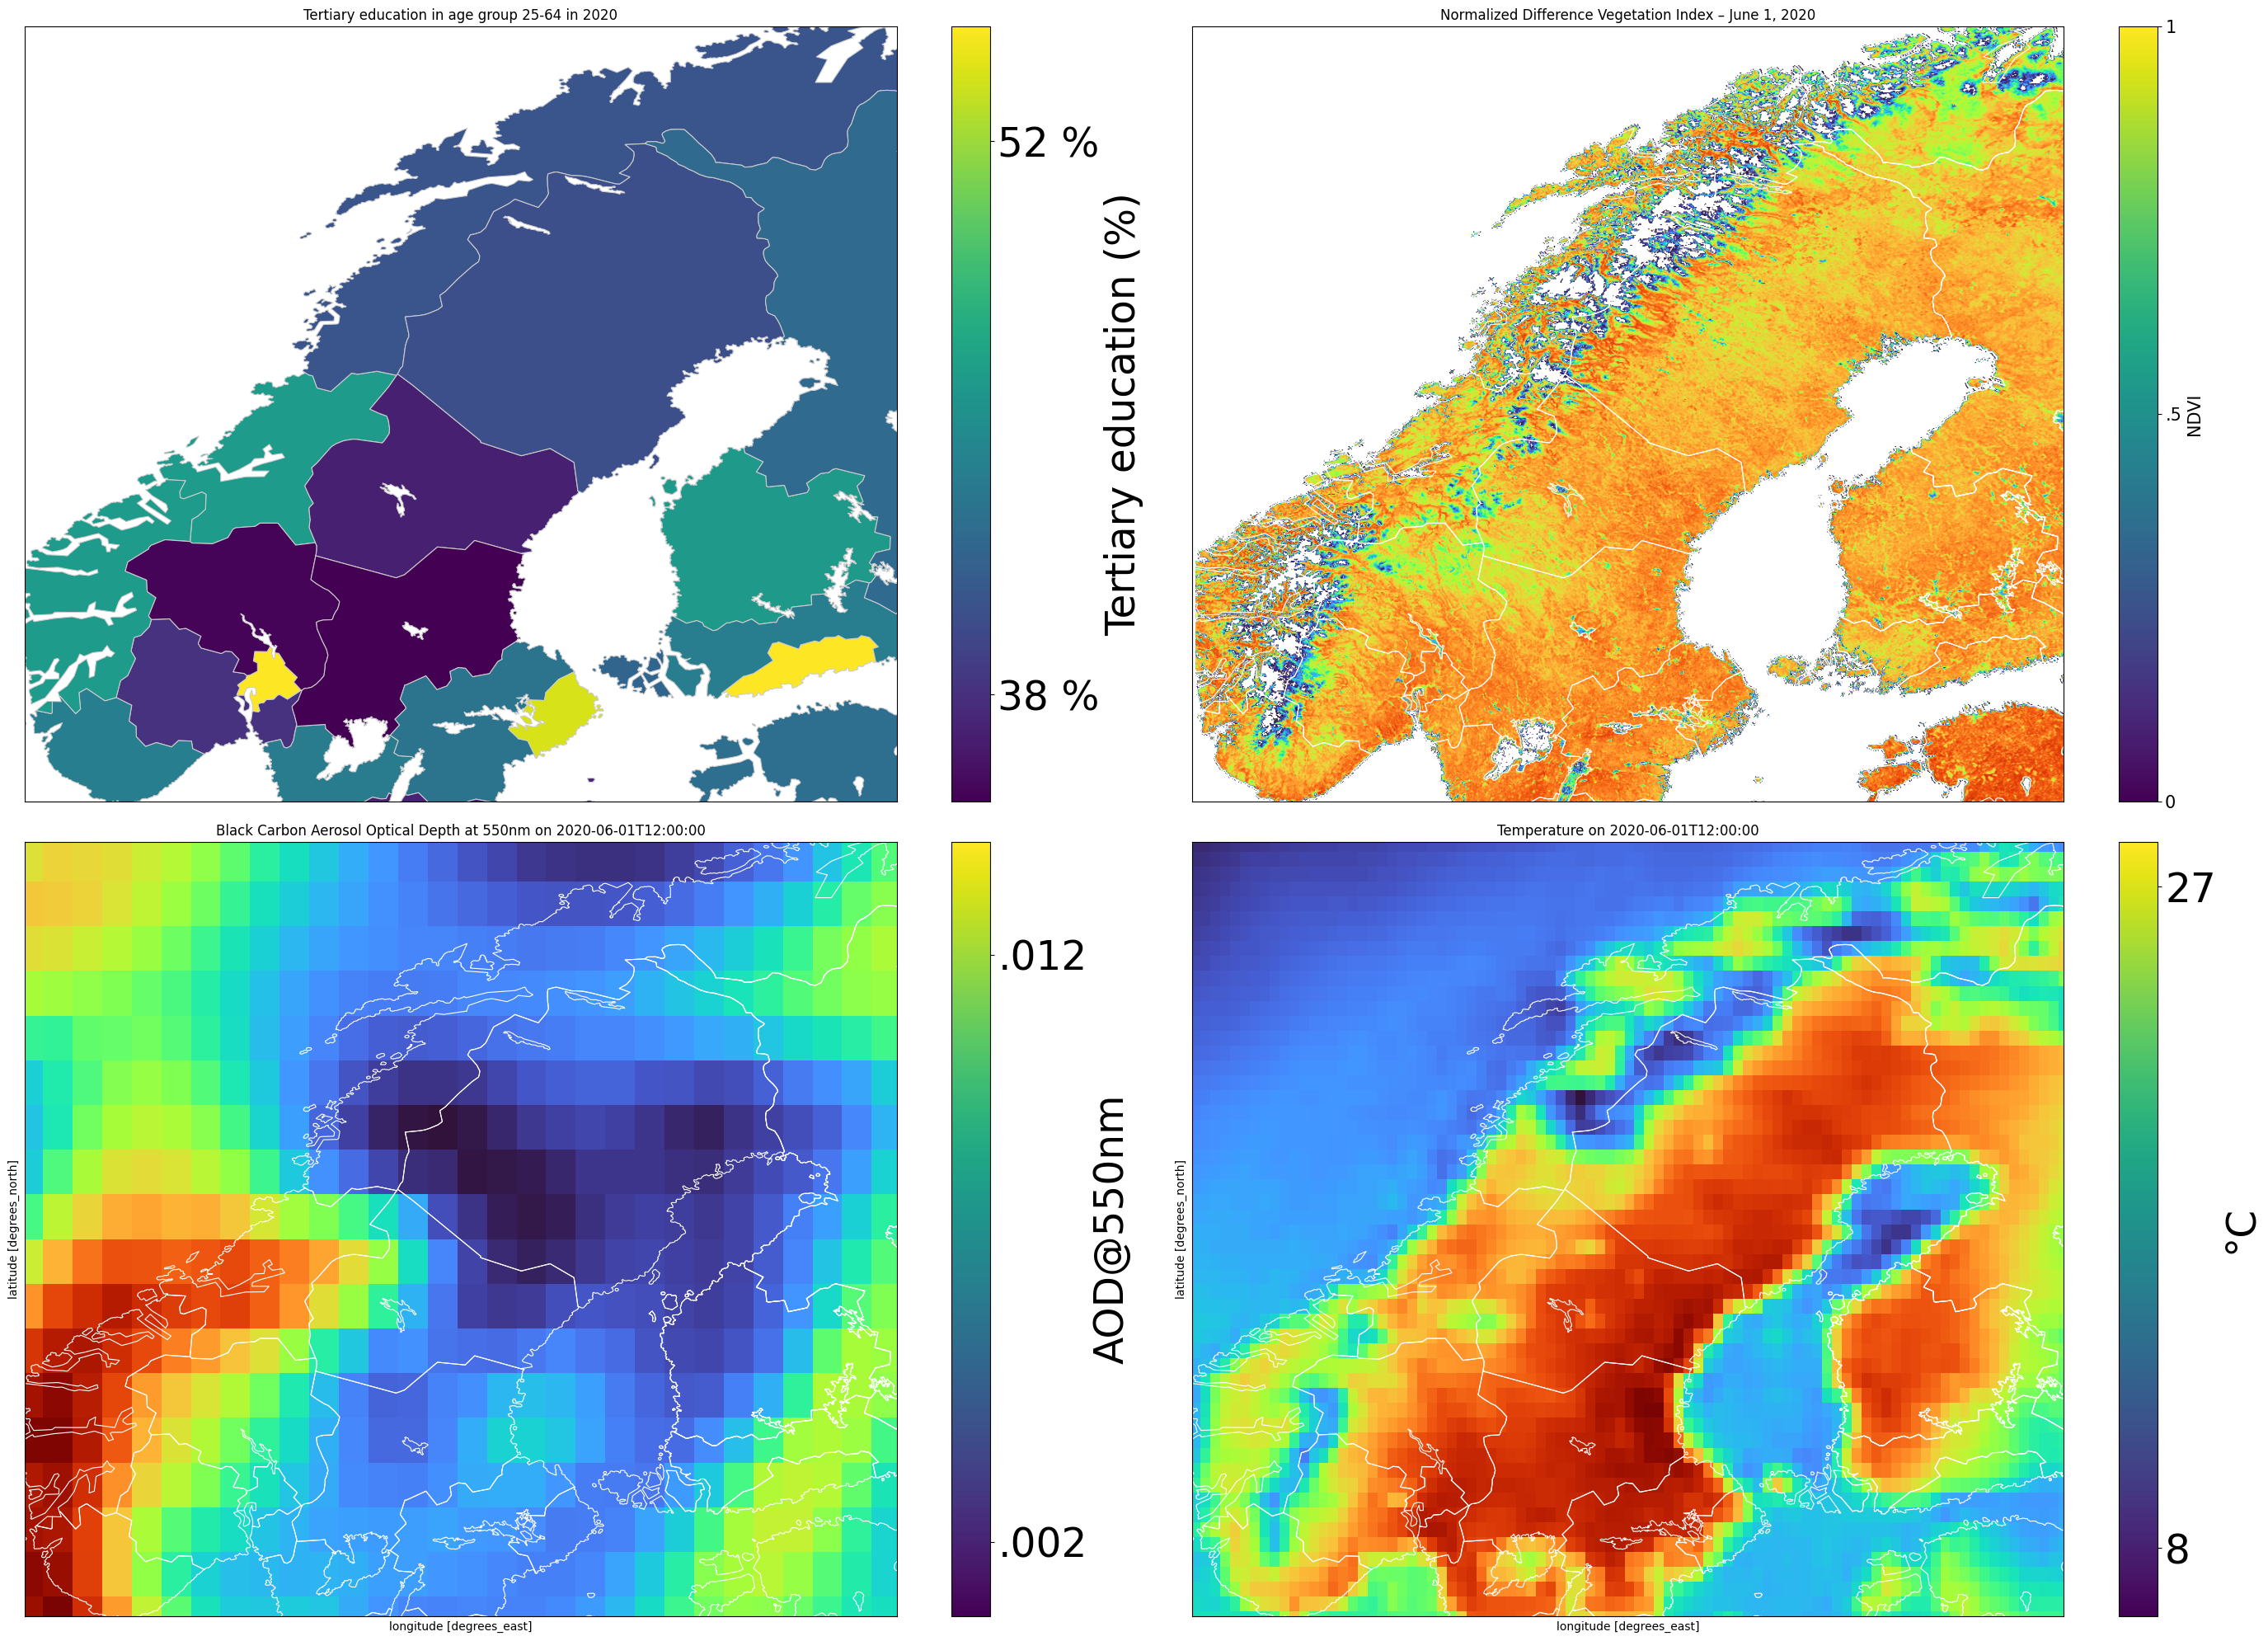

In [170]:
import matplotlib as mpl

# Define consistent geographic extent (lon/lat)
lon_min, lon_max = 4.9, 27
lat_min, lat_max = 58, 71

fig, axes = plt.subplots(2, 2, figsize=(28, 20))

# 1. Socioeconomic data (2020)
year = 2020
filtered_df['x'] = filtered_df[f'y_{year}']
filtered_df.plot(
    column='x',
    cmap='viridis',
    linewidth=0.8,
    ax=axes[0, 0],
    edgecolor='0.8',
)
axes[0, 0].set_title(f"Tertiary education in age group 25-64 in {year}")
axes[0, 0].set_xlim(lon_min, lon_max)
axes[0, 0].set_ylim(lat_min, lat_max)

axes[0, 0].set_aspect('auto')   # <--- here
sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=filtered_df['x'].min(), vmax=filtered_df['x'].max()))
sm._A = []
# Add a colorbar to the figure with a customized label
cbar = fig.colorbar(sm, ax=axes[0, 0], orientation='vertical')
cbar.set_label('Tertiary education (%)', fontsize=35)
# Set tick font size
cbar.ax.tick_params(labelsize=35)

# Set specific ticks (optional)
cbar.set_ticks([38, 52,])

# Format tick labels (optional)
cbar.ax.set_yticklabels(['38 %', '52 %'])

# 2. Land cover (GeoTIFF)
with rasterio.open('test_data/modis_ndvi/2020-06-01.tif') as src:
    image = src.read(1)
    masked = np.ma.masked_less(image, -10)
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

im2 = axes[0, 1].imshow(masked, cmap='turbo', extent=extent, origin='upper')
axes[0, 1].set_title('Normalized Difference Vegetation Index – June 1, 2020')
axes[0, 1].set_xlim(lon_min, lon_max)
axes[0, 1].set_ylim(lat_min, lat_max)

sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=0, vmax=1))
sm._A = []

cbar = fig.colorbar(sm, ax=axes[0, 1], orientation='vertical')

cbar.set_label('NDVI', fontsize=15)
# Set tick font size
cbar.ax.tick_params(labelsize=15)

# Set specific ticks (optional)
cbar.set_ticks([0,.5, 1])

# Format tick labels (optional)
cbar.ax.set_yticklabels(['0 ','.5', '1'])

filtered_df.geometry.boundary.plot(ax=axes[0, 1], edgecolor='white', linewidth=0.8)
axes[0, 1].set_aspect('auto')   # <--- here
#fig.colorbar(im2, ax=axes[0, 1], orientation='vertical', label='NDVI Value')

# ... previous plotting code ...

# 3. Air pollution (AOD)
im3 = bcaod.plot(ax=axes[1, 0], cmap='turbo', add_colorbar=False)
axes[1, 0].set_title(f"Black Carbon Aerosol Optical Depth at 550nm on {date}")
axes[1, 0].set_xlim(lon_min, lon_max)
axes[1, 0].set_ylim(lat_min, lat_max)

sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=bcaod[:].min().item(), vmax=bcaod[:].max().item()))
sm._A = []

cbar = fig.colorbar(sm, ax=axes[1, 0], orientation='vertical')

cbar.set_label('AOD@550nm', fontsize=35)
# Set tick font size
cbar.ax.tick_params(labelsize=35)

# Set specific ticks (optional)
cbar.set_ticks([0.002, 0.012,])

# Format tick labels (optional)
cbar.ax.set_yticklabels(['.002', '.012'])

# Overlay boundaries on plot 3
filtered_df.geometry.boundary.plot(ax=axes[1, 0], edgecolor='white', linewidth=0.8)

axes[1, 0].set_aspect('auto')

# 4. Temperature
t2mC = t2m-273.15
im4 = t2mC.plot(ax=axes[1, 1], cmap='turbo', add_colorbar=False)
axes[1, 1].set_title(f"Temperature on {date}")
axes[1, 1].set_xlim(lon_min, lon_max)
axes[1, 1].set_ylim(lat_min, lat_max)
#fig.colorbar(im4, ax=axes[1, 1], orientation='vertical', label='°C')

sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=t2mC[:].min().item(), vmax=t2mC[:].max().item()))
sm._A = []

cbar = fig.colorbar(sm, ax=axes[1, 1], orientation='vertical')

cbar.set_label('°C', fontsize=35)
# Set tick font size
cbar.ax.tick_params(labelsize=35)

# Set specific ticks (optional)
cbar.set_ticks([8, 27])

# Format tick labels (optional)
cbar.ax.set_yticklabels(['8 ', '27'])

# Overlay boundaries on plot 4
filtered_df.geometry.boundary.plot(ax=axes[1, 1], edgecolor='white', linewidth=0.8)

axes[1, 1].set_aspect('auto')

# Remove redundant x-axis ticks/labels on top row
for ax in axes[1, :]:
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_yticklabels([])
    ax.set_yticks([])

# Remove redundant y-axis ticks/labels on right column
for ax in axes[0, :]:
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_xticks([])

plt.tight_layout()
plt.show()


### Different layout

C:\Users\jents\AppData\Local\Temp\ipykernel_22384\4083834222.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


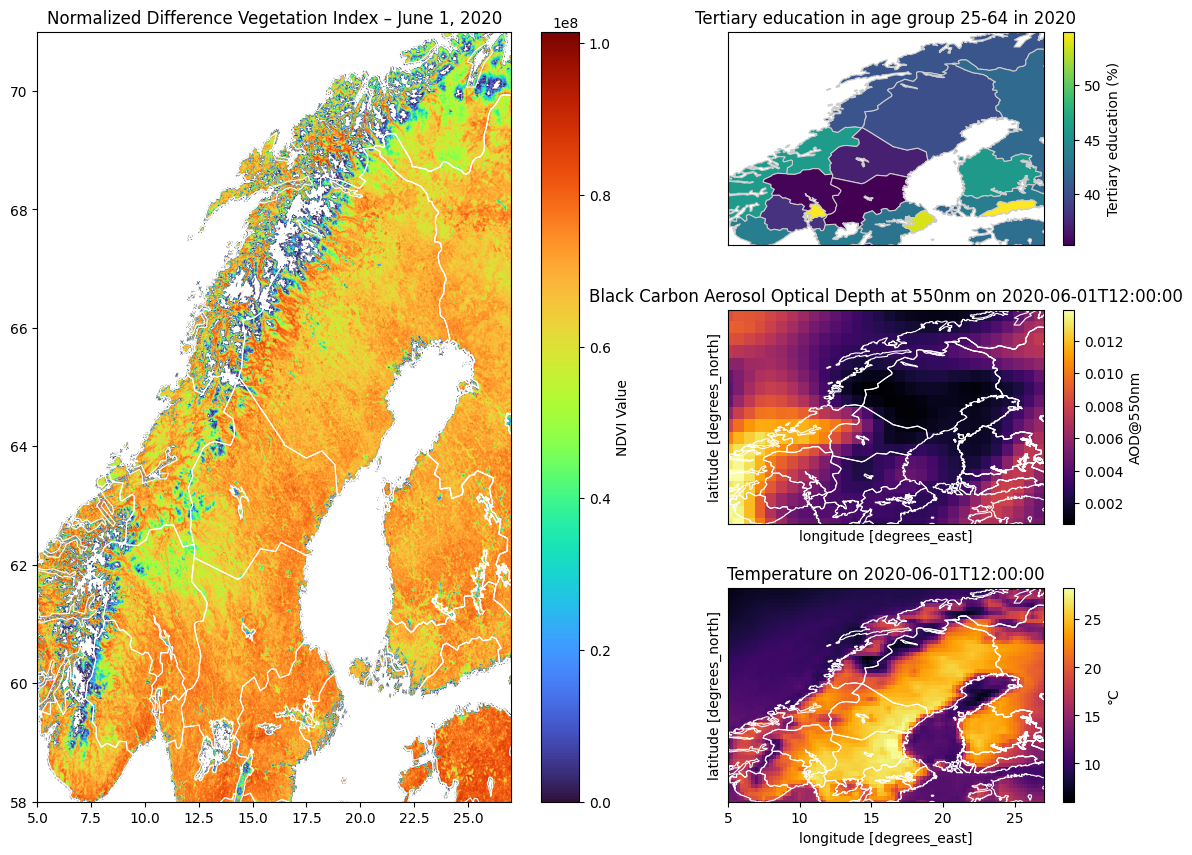

In [131]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import rasterio

# Define consistent geographic extent (lon/lat)
lon_min, lon_max = 5, 27
lat_min, lat_max = 58, 71

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1.5, 1], height_ratios=[1, 1, 1], hspace=0.3, wspace=0.2)


# Axes layout:
# [0, 0] – NDVI
# [0, 1] – Socioeconomic
# [1, 1] – AOD
# [2, 1] – Temperature

ax_ndvi = fig.add_subplot(gs[:, 0])        # NDVI (spans all 3 rows on left)
ax_socio = fig.add_subplot(gs[0, 1])       # Top right
ax_aod = fig.add_subplot(gs[1, 1])         # Middle right
ax_temp = fig.add_subplot(gs[2, 1])        # Bottom right

# 1. Socioeconomic data (2020)
year = 2020
filtered_df['x'] = filtered_df[f'y_{year}']
filtered_df.plot(
    column='x',
    cmap='viridis',
    linewidth=0.8,
    ax=ax_socio,
    edgecolor='0.8',
    legend=False
)
ax_socio.set_title(f"Tertiary education in age group 25-64 in {year}")
ax_socio.set_xlim(lon_min, lon_max)
ax_socio.set_ylim(lat_min, lat_max)
ax_socio.set_aspect('auto')
sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=filtered_df['x'].min(), vmax=filtered_df['x'].max()))
sm._A = []
cbar = fig.colorbar(sm, ax=ax_socio, orientation='vertical')
cbar.set_label('Tertiary education (%)')

# 2. Land cover (NDVI – GeoTIFF)
with rasterio.open('test_data/modis_ndvi/2020-06-01.tif') as src:
    image = src.read(1)
    masked = np.ma.masked_less(image, 0)
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

im2 = ax_ndvi.imshow(masked, cmap='turbo', extent=extent, origin='upper')
ax_ndvi.set_title('Normalized Difference Vegetation Index – June 1, 2020')
ax_ndvi.set_xlim(lon_min, lon_max)
ax_ndvi.set_ylim(lat_min, lat_max)
filtered_df.geometry.boundary.plot(ax=ax_ndvi, edgecolor='white', linewidth=0.8)
ax_ndvi.set_aspect('auto')
fig.colorbar(im2, ax=ax_ndvi, orientation='vertical', label='NDVI Value')

# 3. Air pollution (AOD)
im3 = bcaod.plot(ax=ax_aod, cmap='inferno', add_colorbar=False)
ax_aod.set_title(f"Black Carbon Aerosol Optical Depth at 550nm on {date}")
ax_aod.set_xlim(lon_min, lon_max)
ax_aod.set_ylim(lat_min, lat_max)
filtered_df.geometry.boundary.plot(ax=ax_aod, edgecolor='white', linewidth=0.8)
fig.colorbar(im3, ax=ax_aod, orientation='vertical', label='AOD@550nm')
ax_aod.set_aspect('auto')

# 4. Temperature
t2mC = t2m - 273.15
im4 = t2mC.plot(ax=ax_temp, cmap='inferno', add_colorbar=False)
ax_temp.set_title(f"Temperature on {date}")
ax_temp.set_xlim(lon_min, lon_max)
ax_temp.set_ylim(lat_min, lat_max)
filtered_df.geometry.boundary.plot(ax=ax_temp, edgecolor='white', linewidth=0.8)
fig.colorbar(im4, ax=ax_temp, orientation='vertical', label='°C')
ax_temp.set_aspect('auto')

# Axis cleanup: only show labels where needed
# Remove x-ticks for top two right-side plots
for ax in [ax_socio, ax_aod]:
    ax.set_xticklabels([])
    ax.set_xticks([])

# Remove y-ticks for all right-side plots
for ax in [ax_socio, ax_aod, ax_temp]:
    ax.set_yticklabels([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


In [163]:
x = bcaod[:].min().item()
x


0.0007312505040317774